# Определение

Многомерный (мультивариативный, multivariate time series) временной ряд - это система из нескольких одномерных рядов, где значения одного (целевого) зависят не только от предыдущих значений этого ряда, но и от значений дополнительного, или нескольких дополнительных.

Дополнительные времянные ряды называются экзогенными.

Существует две возможные задачи при прогнозировании мультивариативного временного ряда.
1. 
На момент формирования прогноза будут доступны данные экзогенных временных рядов только на текущий момент времени и предыстория, то есть t, t-1, t-2, t-n, в то время как данные на индексы прогноза t+1, t+2, t+f (где f - горизонт прогнозирования), неизвестны.
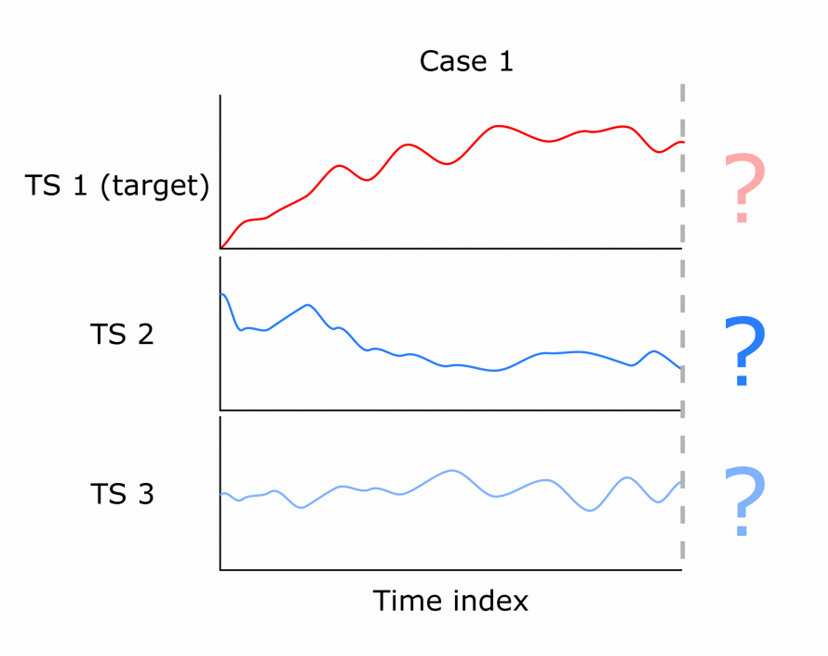

2.
Для целевого временного ряда значения на прогнозные индексы неизвестны, но зато есть информация об экзогенных в эти моменты времени.

Это задача регрессии, однако, поскольку данные упорядочены во времени, есть возможность решать “динамическую регрессию”, которая учитывает ещё и лаговые взаимосвязи в данных.
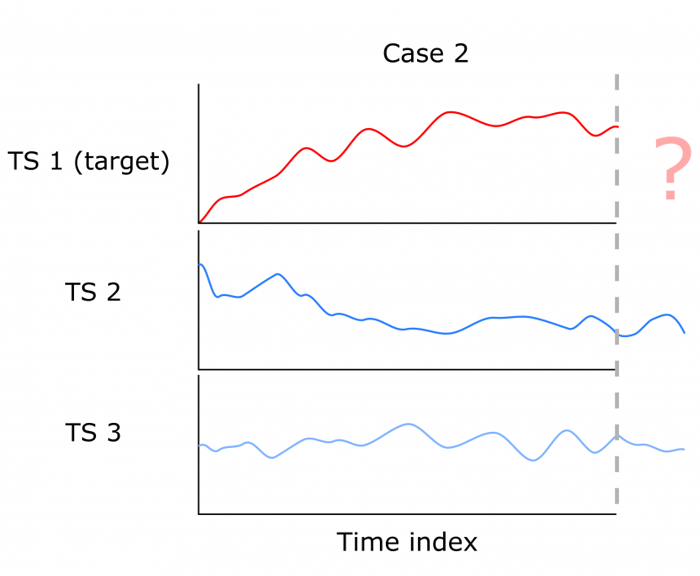



# Vector Auto Regression (VAR)

Векторная авторегрессия - один из наиболее используемых в настоящее время алгоритмов для предсказания мультивариативных временных рядов.

В алгоритме VAR каждая переменная является линейной функцией прошлых значений самой себя и прошлых значений всех других переменных. 

Допустим у нас есть две переменные: y1 и y2. Нам нужно спрогнозировать значение этих двух переменных в момент времени «t» на основе данных для прошлых n значений. Для простоты примем лаг равным 1.

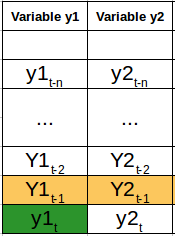 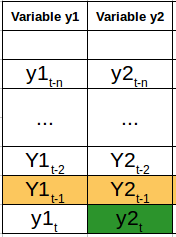

Чтобы вычислить y1(t), мы будем использовать прошлые значения y1 и y2. Аналогично, для вычисления y2(t) будут использоваться прошлые значения как y1, так и y2.

Простой математический способ представления этого отношения (Пусть это будет система уравнений 1):

 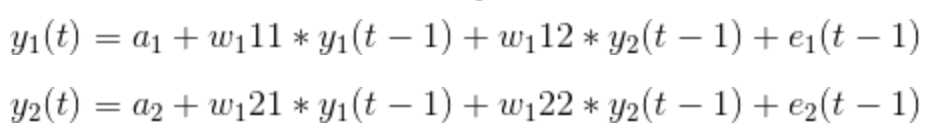

где
a1 и a2 — постоянные члены,
w11, w12, w21 и w22 — коэффициенты,
e1 и e2 — члены ошибки
Эти уравнения аналогичны уравнению процесса АР. Поскольку процесс AR используется для одномерных данных временных рядов, будущие значения представляют собой линейные комбинации только своих прошлых значений. Рассмотрим процесс AR(1):
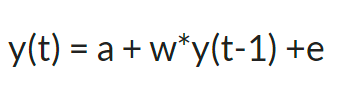

В этом случае у нас есть только одна переменная – y, постоянный член – a,  ошибка – e и коэффициент – w. Чтобы учесть несколько переменных членов в каждом уравнении для VAR, мы будем использовать векторы. Уравнения (1)  можно записать в следующем векторном виде:

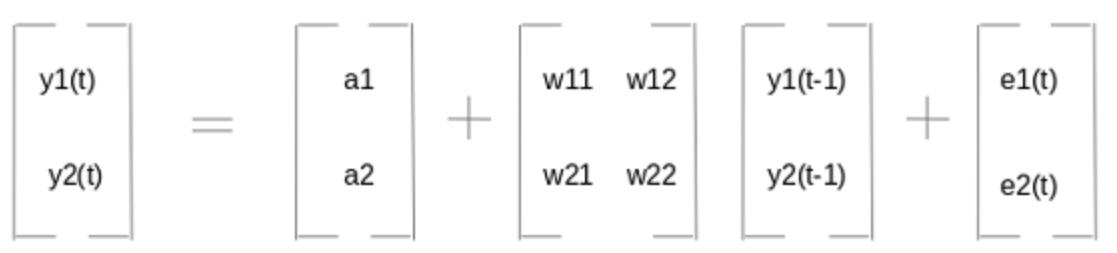


Двумя переменными являются y1 и y2, за которыми следуют вектор констант, тензор коэффициентов, вектор значений с задержкой и вектор  ошибок. Это векторное уравнение для процесса VAR(1). Для процесса VAR(2) к уравнению будет добавлен еще один векторный член для времени (t-2) для обобщения задержек p:
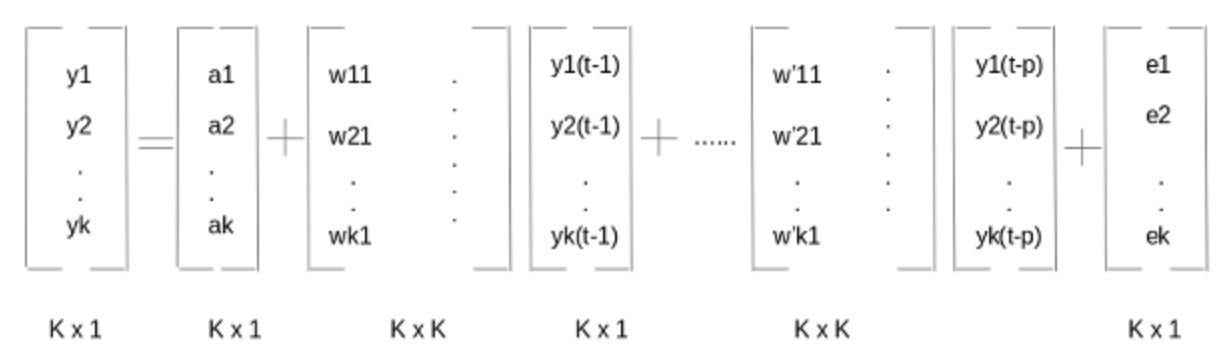

Ну или в другом виде это запишется в виде:
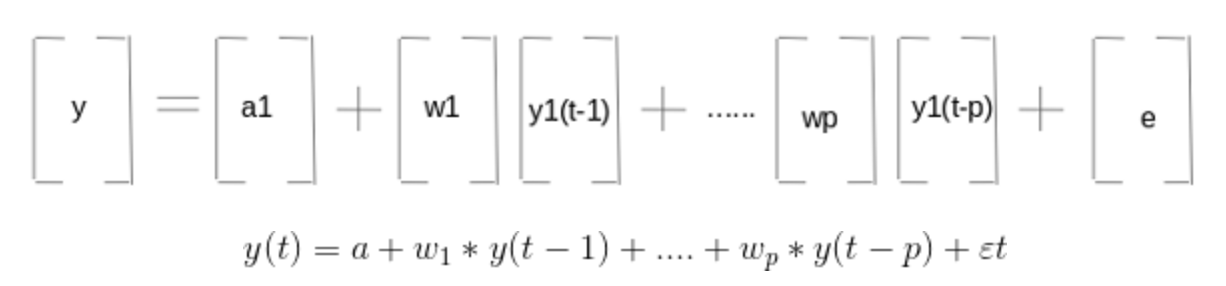

При этом должно выполняться:
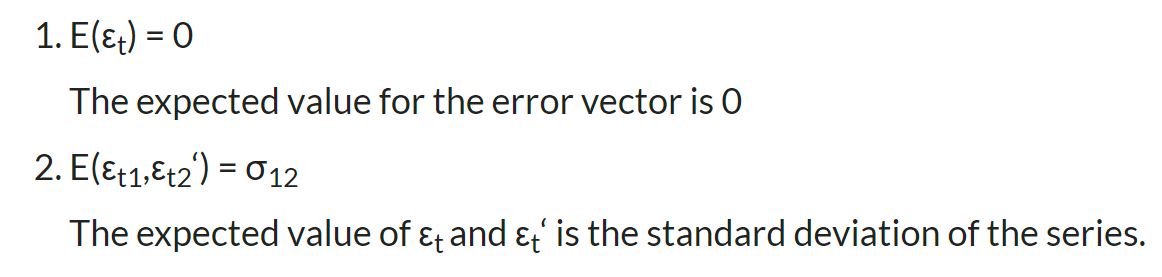

Granger causality test

Тест Грэнджера на причинность (англ. Granger causality test) — процедура проверки причинной (не причинно-следственной (!) связи («причинность по Грэнджеру»)

Тест можно использовать для выявления взаимосвязи между переменными до построения модели. Это важно, поскольку если между переменными нет связи, их можно исключить и смоделировать отдельно. И наоборот, если существует взаимосвязь, переменные необходимо учитывать на этапе моделирования.

Тест дает p-значение для переменных. Если значение p превышает 0,05, необходимо принять нулевую гипотезу. И наоборот, если значение p меньше 0,05, нулевую гипотезу следует отклонить.

В тесте Грэнджера последовательно проверяются две нулевые гипотезы: «x не является причиной y по Грэнджеру» и «у не является причиной x по Грэнджеру». Для проверки этих гипотез строятся две регрессии: в каждой регрессии зависимой переменной является одна из проверяемых на причинность переменных, а регрессорами выступают лаги обеих переменных (фактически это векторная авторегрессия).

${\displaystyle y_{t}=a_{0}+a_{1}y_{t-1}+...+a_{p}y_{t-p}+b_{1}x_{t-1}+...+b_{p}x_{t-p}+\varepsilon _{t}}$
 
${\displaystyle x_{t}=c_{0}+c_{1}x_{t-1}+...+c_{p}x_{t-p}+d_{1}y_{t-1}+...+d_{p}y_{t-p}+u_{t}}$

Для каждой регрессии нулевая гипотеза заключается в том, что коэффициенты при лагах второй переменной одновременно равны нулю.

${\displaystyle H_{0}^{1}:~b_{1}=...=b_{p}=0}$

${\displaystyle H_{0}^{2}:~d_{1}=...=d_{p}=0}$

Данные гипотезы можно проверить, например, с помощью F-теста или LM-теста. Необходимо отметить, что результаты теста могут зависеть от количества использованных лагов в регрессиях.

# Stationarity of a Multivariate Time Series

Стационарные ряды предсказываются лучше, чем нестационнарные. Подобно расширенному тесту Дики-Фуллера для одномерных рядов, у нас есть тест Йохансена для проверки стационарности любых данных многомерных временных рядов.

# Train-Validation Split

На трейн, тест и валидационные наборы необходимо делить с учетом временных интервалов, не перемешивая значения.

Рассмотрим мультивариативный ряд

Данные взяты с химического мультисенсорного устройства качества воздуха. 
Устройство было расположено на поле в значительно загрязненной зоне, на уровне дороги в итальянском городе. Данные были записаны с марта 2004 г. по февраль 2005 г. (один год) и представляют собой самые длительные свободно доступные записи реакций химических датчиков качества воздуха, развернутых на местах. Усредненные почасовые концентрации Ground Truth для CO, неметановых углеводородов, бензола, общих оксидов азота (NOx) и диоксида азота (NO2) были получены с помощью расположенного рядом эталонного сертифицированного анализатора. Свидетельства перекрестной чувствительности, а также дрейфа как концепций, так и датчиков присутствуют, как описано в De Vito et al., Sens. And Act. Б, Том. 129,2,2008 (требуется ссылка), что в конечном итоге влияет на возможности оценки концентрации датчиков. Отсутствующие значения помечены значением -200.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Import Statsmodels
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [4]:
df = pd.read_csv("AirQualityUCI.csv", parse_dates=[['Date', 'Time']], sep = ";",decimal =",")

df['Date_Time'] = pd.to_datetime(df.Date_Time , format = '%d/%m/%Y %H.%M.%S')
data = df.drop(['Date_Time'], axis=1)
data.index = df.Date_Time

C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\2274929881.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("AirQualityUCI.csv", parse_dates=[['Date', 'Time']], sep = ";",decimal =",")
C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\2274929881.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("AirQualityUCI.csv", parse_dates=[['Date', 'Time']], sep = ";",decimal =",")


In [5]:
data.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Date_Time,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [6]:
data.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [7]:
data.dtypes

CO(GT)           float64
PT08.S1(CO)        int64
NMHC(GT)           int64
C6H6(GT)         float64
PT08.S2(NMHC)      int64
NOx(GT)            int64
PT08.S3(NOx)       int64
NO2(GT)            int64
PT08.S4(NO2)       int64
PT08.S5(O3)        int64
T                float64
RH               float64
AH               float64
dtype: object

In [8]:
data.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH'],
      dtype='object')

In [9]:
df = data.copy()

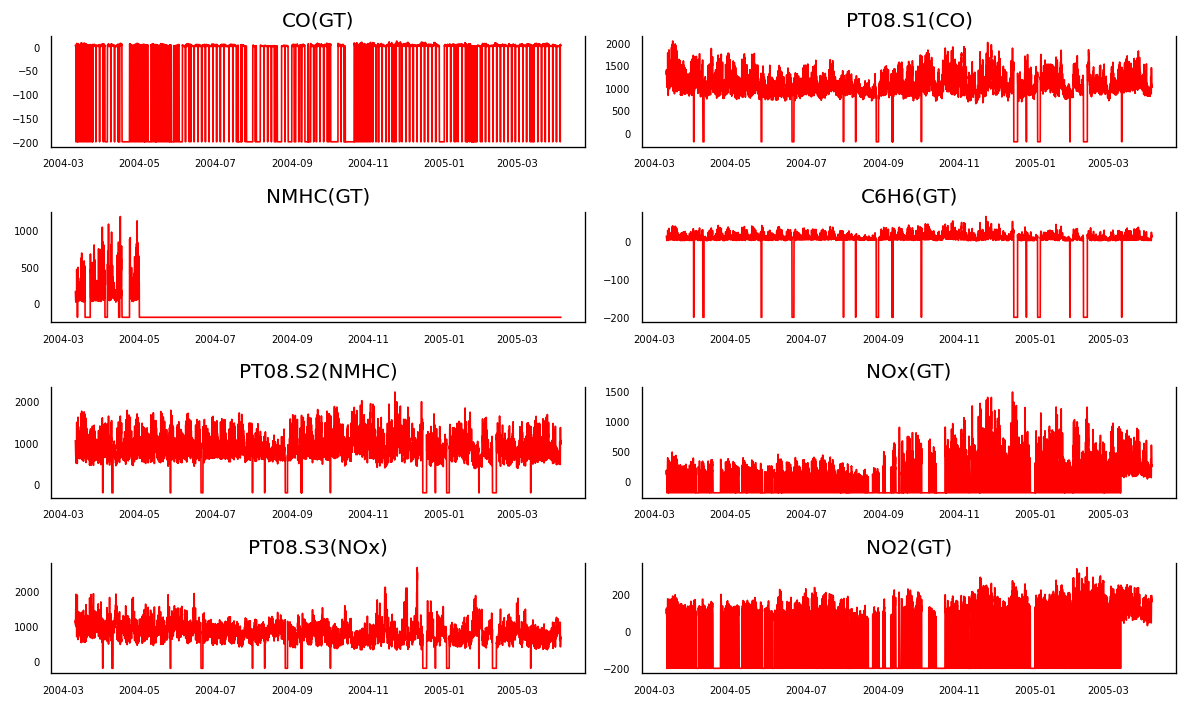

In [10]:
# Plot
fig, axes = plt.subplots(nrows=4, ncols=2, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df[df.columns[i]]
    ax.plot(data, color='red', linewidth=1)
    # Decorations
    ax.set_title(df.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout();

Работа с отсутствующими значениями
Следующий шаг — разобраться с пропущенными значениями. Не всегда целесообразно использовать df.dropna. Поскольку пропущенные значения в данных заменяются значением -200, нам придется заменить недостающее значение лучшим числом. 

Если текущее значение точки росы отсутствует, мы можем с уверенностью предположить, что оно будет близко к значению предыдущего часа. Будем вместо -200  запиывать предыдущее значение.

Можно использовать другие вариант борьбы с пропусками.

In [11]:
# заменяем отсутствующие значения

cols = df.columns
 
for j in range(1,len(cols)):
    for i in range(0,len(df.iloc[:,j])):
       if df.iloc[i,j] == -200.0:
           df.iloc[i,j] = df.iloc[i,j-1]

           

C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\238310353.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.7' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[i,j] = df.iloc[i,j-1]
C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\238310353.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.2' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[i,j] = df.iloc[i,j-1]
C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\238310353.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.2' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.iloc[i,j] = df.iloc[i,j-1]
C:\Users\Syoshi\AppData\Local\Temp\ipyke

In [12]:
# Проверяем стационарность

from statsmodels.tsa.vector_ar.vecm import coint_johansen
#since the test works for only 12 variables, I have randomly dropped
#in the next iteration, I would drop another and check the eigenvalues
johan_test_temp = df.drop([ 'CO(GT)'], axis=1)
coint_johansen(johan_test_temp,-1,1).eig

array([0.17408382, 0.16362687, 0.09546836, 0.06650654, 0.06143461,
       0.05048135, 0.03757558, 0.03121995, 0.0270527 , 0.00606444,
       0.0041724 , 0.00065524])

In [13]:
# granger causality tests

from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    """Check Granger Causality of all possible combinations of the Time series.
    The rows are the response variable, columns are predictors. The values in the table 
    are the P-Values. P-Values lesser than the significance level (0.05), implies 
    the Null Hypothesis that the coefficients of the corresponding past values is 
    zero, that is, the X does not cause Y can be rejected.
    data      : pandas dataframe containing the time series variables
    variables : list containing names of the time series variables.
    """
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

In [14]:
grangers_causation_matrix(df, variables = df.columns) 

c:\Users\Syoshi\miniconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Syoshi\miniconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\Syoshi\miniconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\Syoshi\miniconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\Syoshi\miniconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not pr

,CO(GT)_x,PT08.S1(CO)_x,NMHC(GT)_x,C6H6(GT)_x,PT08.S2(NMHC)_x,NOx(GT)_x,PT08.S3(NOx)_x,NO2(GT)_x,PT08.S4(NO2)_x,PT08.S5(O3)_x,T_x,RH_x,AH_x
CO(GT)_y,1.0000,0.0,0.0,0.0000,0.0,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0003,0.0002
PT08.S1(CO)_y,0.0000,1.0,0.0,0.0000,0.0,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0000
NMHC(GT)_y,0.0000,0.0,1.0,0.0000,0.0,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0000
C6H6(GT)_y,0.0000,0.0,0.0,1.0000,0.0,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0000
PT08.S2(NMHC)_y,0.0000,0.0,0.0,0.0000,1.0,0.0000,0.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0000
NOx(GT)_y,0.0000,0.0,0.0,0.0000,0.0,1.0000,0.0,0.0000,0.0,0.0000,0.0020,0.0002,0.0308
PT08.S3(NOx)_y,0.0000,0.0,0.0,0.0000,0.0,0.0000,1.0,0.0000,0.0,0.0000,0.0000,0.0000,0.0000
NO2(GT)_y,0.0000,0.0,0.0,0.0000,0.0,0.0000,0.0,1.0000,0.0,0.0000,0.2612,0.0000,0.1174
PT08.S4(NO2)_y,0.0000,0.0,0.0,0.0000,0.0,0.0000,0.0,0.0000,1.0,0.0000,0.0012,0.0000,0.0000
PT08.S5(O3)_y,0.0000,0.0,0.0,0.0001,0.0,0.0000,0.0,0.0000,0.0,1.0000,0.0000,0.0000,0.0000


# Коинтегральность

Когда два или более временных ряда коинтегрированы, это означает, что они имеют долгосрочную, статистически значимую связь.

Это основная предпосылка, на которой основаны модели векторной авторегрессии (VAR).
Итак, довольно часто перед началом построения VAR-моделей проводят тест на коинтеграцию.

более технически:
Порядок интегрирования (d) — это не что иное, как количество разностей, необходимое для того, 
чтобы сделать нестационарный временной ряд стационарным.

Теперь, когда у вас есть два или более временных ряда и существует их линейная комбинация, 
у которой порядок интегрирования (d) меньше, чем у отдельного ряда, тогда совокупность рядов называется коинтегрированной.

In [15]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df, alpha=0.05): 
    """Perform Johanson's Cointegration Test and Report Summary"""
    out = coint_johansen(df,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    # Summary
    print('Name   ::  Test Stat > C(95%)    =>   Signif  \n', '--'*20)
    for col, trace, cvt in zip(df.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)



In [16]:
cointegration_test(df)

Name   ::  Test Stat > C(95%)    =>   Signif  
 ----------------------------------------
CO(GT) ::  4945.27   > nan       =>   False
PT08.S1(CO) ::  3131.83   > 311.1288  =>   True
NMHC(GT) ::  2367.06   > 263.2603  =>   True
C6H6(GT) ::  1734.6    > 219.4051  =>   True
PT08.S2(NMHC) ::  1360.3    > 179.5199  =>   True
NOx(GT) ::  1055.66   > 143.6691  =>   True
PT08.S3(NOx) ::  779.0     > 111.7797  =>   True
NO2(GT) ::  549.68    > 83.9383   =>   True
PT08.S4(NO2) ::  340.79    > 60.0627   =>   True
PT08.S5(O3) ::  169.64    > 40.1749   =>   True
T      ::  62.54     > 24.2761   =>   True
RH     ::  24.77     > 12.3212   =>   True
AH     ::  4.37      > 4.1296    =>   True


C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\3054894920.py:5: HypothesisTestWarning: Critical values are only available for time series with 12 variables at most.
  out = coint_johansen(df,-1,5)


In [17]:
# Стационарность
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")  

In [18]:
# Разделяем выборку на трейн и тест
#creating the train and validation set
train = df[:int(0.8*(len(data)))]
test = df[int(0.8*(len(data))):]



In [19]:
for name, column in train.items():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "CO(GT)" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -8.6091
 No. Lags Chosen       = 26
 Critical value 1%     = -3.431
 Critical value 5%     = -2.862
 Critical value 10%    = -2.567
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "PT08.S1(CO)" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -10.055
 No. Lags Chosen       = 29
 Critical value 1%     = -3.431
 Critical value 5%     = -2.862
 Critical value 10%    = -2.567
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "NMHC(GT)" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance L

In [20]:
# если нестационарный, то удаляем тренд (помните дифференцирование ?) и опять проверяеми
# 1st difference
df_differenced = train.diff().dropna()

# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.items():
    adfuller_test(column, name=column.name)
    print('\n')



    Augmented Dickey-Fuller Test on "CO(GT)" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -17.5248
 No. Lags Chosen       = 33
 Critical value 1%     = -3.431
 Critical value 5%     = -2.862
 Critical value 10%    = -2.567
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "PT08.S1(CO)" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -17.4567
 No. Lags Chosen       = 36
 Critical value 1%     = -3.431
 Critical value 5%     = -2.862
 Critical value 10%    = -2.567
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "NMHC(GT)" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance

In [21]:
# если опять нестационарные - опять дифференцируем


df_differenced = df_differenced.diff().dropna()

# ADF Test on each column of 2nd Differences Dataframe
for name, column in df_differenced.items():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "CO(GT)" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -25.3591
 No. Lags Chosen       = 36
 Critical value 1%     = -3.431
 Critical value 5%     = -2.862
 Critical value 10%    = -2.567
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "PT08.S1(CO)" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -28.4827
 No. Lags Chosen       = 34
 Critical value 1%     = -3.431
 Critical value 5%     = -2.862
 Critical value 10%    = -2.567
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "NMHC(GT)" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance

In [22]:
# Чтобы выбрать правильный порядок модели VAR, мы итеративно подбираем возрастающие порядки модели VAR и выбираем порядок, который дает модель с наименьшим AIC.

from statsmodels.tsa.vector_ar.var_model import VAR


model = VAR(df_differenced)
for i in [1,2,3,4,5,6,7,8,9]:
    result = model.fit(i)
    print('Lag Order =', i)
    print('AIC : ', result.aic)
    print('BIC : ', result.bic)
    print('FPE : ', result.fpe)
    print('HQIC: ', result.hqic, '\n')




Lag Order = 1
AIC :  96.26300474817228
BIC :  96.4313402848621
FPE :  6.404596861787598e+41
HQIC:  96.32081685017323 

Lag Order = 2
AIC :  94.30636966736664
BIC :  94.6310538987404
FPE :  9.051824639813765e+40
HQIC:  94.41787793314126 

Lag Order = 3
AIC :  93.05167918627401
BIC :  93.53274787569963
FPE :  2.5812577802802784e+40
HQIC:  93.21689661857694 

Lag Order = 4
AIC :  92.23353220687662
BIC :  92.87102113085577
FPE :  1.1389782304888903e+40
HQIC:  92.45247181337605 

Lag Order = 5
AIC :  91.68640626722558
BIC :  92.48035121540033
FPE :  6.590265256743221e+39
HQIC:  91.95908106050578 

Lag Order = 6
AIC :  91.22044043624659
BIC :  92.17087721140601
FPE :  4.135598394537361e+39
HQIC:  91.54686343381044 

Lag Order = 7
AIC :  90.89324092345473
BIC :  92.00020534154145
FPE :  2.981535539338733e+39
HQIC:  91.27342514772619 

Lag Order = 8
AIC :  90.59384620548228
BIC :  91.85737409559913
FPE :  2.2101305856194936e+39
HQIC:  91.02780468380894 



c:\Users\Syoshi\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Lag Order = 9
AIC :  90.37346582834206
BIC :  91.79359303275866
FPE :  1.7730146915217835e+39
HQIC:  90.86121159299763 



In [23]:
# другой вариает - автозаполнение. Лучшие метрики выделены *

x = model.select_order(maxlags=12)
x.summary()

,AIC,BIC,FPE,HQIC
0,100.7,100.7,5.408e+43,100.7
1,96.26,96.43,6.374e+41,96.32
2,94.30,94.63,9.025e+40,94.42
3,93.05,93.53,2.575e+40,93.21
4,92.23,92.87,1.135e+40,92.45
5,91.68,92.48,6.562e+39,91.95
6,91.21,92.17,4.112e+39,91.54
7,90.89,91.99,2.960e+39,91.27
8,90.59,91.86,2.208e+39,91.03
9,90.37,91.79,1.774e+39,90.86


In [24]:
# заполняем модель с лучшими параметрами
model_fitted = model.fit(12)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 01, Jun, 2026
Time:                     22:07:07
--------------------------------------------------------------------
No. of Equations:         13.0000    BIC:                    91.5815
Nobs:                     7471.00    HQIC:                   90.3405
Log likelihood:          -470813.    FPE:                8.96362e+38
AIC:                      89.6913    Det(Omega_mle):     6.84019e+38
--------------------------------------------------------------------
Results for equation CO(GT)
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                    -0.000648         0.371426           -0.002           0.999
L1.CO(GT)                -1.452902         0.012200         -119.088           0.000
L1.PT08.S1(CO)            0.019133         

# проверяяем оставшуюся последовательную корреляцию

Последовательная корреляция остатков используется для проверки наличия в остатках какого-либо остаточного шаблона (ошибок). Если в остатках осталась какая-либо корреляция, то во временном ряду есть некоторая закономерность, которую еще предстоит объяснить с помощью модели. В этом случае типичный образ действий — либо увеличить порядок модели, либо ввести в систему больше предикторов, либо искать другой алгоритм для моделирования временного ряда.

Распространенный способ проверки серийной корреляции ошибок можно измерить с помощью статистики Дурбина Уотсона.

Значение этой статистики может варьироваться от 0 до 4. Чем ближе она к значению 2, тем значимой последовательной корреляции нет. Чем ближе к 0, существует положительная последовательная корреляция, а чем ближе к 4, подразумевается отрицательная последовательная корреляция.

In [25]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

# for col, val in zip(df.columns, out):
#    print(adjust(col), ':', round(val, 2))
    
for col, val in zip(df.columns, out):
    print(col, ':', round(val, 2))

CO(GT) : 2.01
PT08.S1(CO) : 2.01
NMHC(GT) : 2.02
C6H6(GT) : 2.01
PT08.S2(NMHC) : 2.02
NOx(GT) : 2.01
PT08.S3(NOx) : 2.02
NO2(GT) : 2.02
PT08.S4(NO2) : 2.02
PT08.S5(O3) : 2.03
T : 2.0
RH : 2.0
AH : 2.0


Для прогнозирования модель VAR ожидает количество наблюдений, равное порядку задержки (лагов), на основе прошлых данных. Это связано с тем, что члены модели VAR по сути являются лагами различных временных рядов в наборе данных, поэтому вам необходимо предоставить столько предыдущих значений, сколько указано в порядке запаздывания, используемом моделью.

In [26]:
# получаем значение лага
lag_order = model_fitted.k_ar
print(lag_order) 

12


In [27]:
# данные для предсказания
forecast_input = df_differenced.values[-lag_order:]
forecast_input

array([[ 7.000e-01,  7.000e+01,  7.000e+01,  6.000e-01,  1.500e+01,
         7.140e+02,  3.000e+00,  7.030e+02,  3.100e+01,  3.800e+01,
        -1.300e+00,  5.600e+00, -5.300e-03],
       [ 4.000e-01,  9.000e+00,  9.000e+00,  1.500e+00,  6.500e+01,
        -1.114e+03, -2.100e+01, -1.345e+03,  4.500e+01,  2.500e+01,
         8.000e-01, -4.600e+00, -5.200e-03],
       [-3.000e-01, -4.900e+01, -4.900e+01, -1.600e+00, -8.000e+01,
         5.730e+02,  7.900e+01,  6.840e+02, -6.700e+01, -2.100e+01,
         1.100e+00, -5.600e+00, -4.900e-03],
       [ 1.000e-01,  9.600e+01,  9.600e+01,  2.000e+00,  1.020e+02,
        -1.100e+01, -1.170e+02, -1.900e+01,  8.600e+01,  1.010e+02,
        -6.000e-01,  5.800e+00,  2.310e-02],
       [ 4.000e-01,  3.800e+01,  3.800e+01,  6.000e-01,  3.000e+01,
         1.210e+02, -6.200e+01,  2.600e+01,  1.500e+01,  9.500e+01,
        -1.000e+00,  5.200e+00,  9.000e-03],
       [-2.000e-01, -1.320e+02, -1.320e+02, -1.500e+00, -7.800e+01,
        -3.200e+01,  1.380e

In [28]:
# Forecast
nobs = 20 # количество точек для предсказания
fc = model_fitted.forecast(y=forecast_input, steps=nobs) # nobs defined at top of program
df_forecast = pd.DataFrame(fc, index=df.index[-nobs:], columns=df.columns + '_2d')
df_forecast

,CO(GT)_2d,PT08.S1(CO)_2d,NMHC(GT)_2d,C6H6(GT)_2d,PT08.S2(NMHC)_2d,NOx(GT)_2d,PT08.S3(NOx)_2d,NO2(GT)_2d,PT08.S4(NO2)_2d,PT08.S5(O3)_2d,T_2d,RH_2d,AH_2d
Date_Time,,,,,,,,,,,,,
2005-04-03 19:00:00,-1.324578,24.829327,24.313329,0.969304,42.477190,-53.758259,-49.144296,-72.100073,26.469611,25.713851,2.165816,-1.548203,1.218722
2005-04-03 20:00:00,9.354943,28.517079,25.505072,-0.251716,24.556837,89.343994,-3.439936,96.383240,25.671186,26.762361,-2.124234,-1.977640,-2.221483
2005-04-03 21:00:00,-11.744837,-29.940313,-32.610230,0.286752,-10.417114,-44.296321,-10.068170,-27.227112,-19.758794,-8.634243,1.763470,2.213242,2.582040
2005-04-03 22:00:00,7.951889,12.229099,16.261145,0.168306,6.703050,48.780744,4.064879,50.231734,16.395369,6.403640,-1.321757,-1.039362,-1.501071
2005-04-03 23:00:00,-9.037416,-35.295999,-34.058324,-1.257289,-46.582360,-62.265163,30.001992,-58.995470,-51.585412,-45.598549,-0.169770,0.601457,0.276900
2005-04-04 00:00:00,7.810988,-6.515486,1.956573,-1.175022,-13.931689,-5.397044,1.797533,7.939898,-5.907639,-19.913153,-1.050874,-0.679583,-1.146106
2005-04-04 01:00:00,-6.167016,8.173603,0.734660,1.410117,11.640723,34.523164,17.057054,28.339574,10.330783,6.261603,1.806456,-0.036804,1.213716
2005-04-04 02:00:00,-0.314552,-17.118255,-15.603583,-1.710334,-21.349582,-32.959023,3.551921,-16.481589,-23.798549,-38.389954,-0.397694,-0.475039,-0.510737
2005-04-04 03:00:00,3.727377,44.653336,36.438962,1.555775,48.047354,29.687540,-31.129331,-13.620302,43.278965,71.114986,-0.072475,-0.962681,-0.305577


Вспоминаем, что для предсказания мы модифицировали датасет. (мы его дифференцировали). Теперь надо обратно вернуть.

In [29]:
def invert_transformation(df_train, df_forecast, second_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        # Roll back 2nd Diff
        if second_diff:
            df_fc[str(col)+'_1d'] = (df_train[col].iloc[-1]-df_train[col].iloc[-2]) + df_fc[str(col)+'_2d'].cumsum()
        # Roll back 1st Diff
        df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [30]:
cl = ['CO(GT)_2d', 'PT08.S1(CO)_2d', 'NMHC(GT)_2d', 'C6H6(GT)_2d', 'PT08.S2(NMHC)_2d',
      'NOx(GT)_2d', 'PT08.S3(NOx)_2d', 'NO2(GT)_2d', 'PT08.S4(NO2)_2d', 'PT08.S5(O3)_2d', 'T_2d', 'RH_2d', 'AH_2d'] 
df_results = invert_transformation(train, df_forecast, second_diff=True)        
df_results.loc[:, cl]

,CO(GT)_2d,PT08.S1(CO)_2d,NMHC(GT)_2d,C6H6(GT)_2d,PT08.S2(NMHC)_2d,NOx(GT)_2d,PT08.S3(NOx)_2d,NO2(GT)_2d,PT08.S4(NO2)_2d,PT08.S5(O3)_2d,T_2d,RH_2d,AH_2d
Date_Time,,,,,,,,,,,,,
2005-04-03 19:00:00,-1.324578,24.829327,24.313329,0.969304,42.477190,-53.758259,-49.144296,-72.100073,26.469611,25.713851,2.165816,-1.548203,1.218722
2005-04-03 20:00:00,9.354943,28.517079,25.505072,-0.251716,24.556837,89.343994,-3.439936,96.383240,25.671186,26.762361,-2.124234,-1.977640,-2.221483
2005-04-03 21:00:00,-11.744837,-29.940313,-32.610230,0.286752,-10.417114,-44.296321,-10.068170,-27.227112,-19.758794,-8.634243,1.763470,2.213242,2.582040
2005-04-03 22:00:00,7.951889,12.229099,16.261145,0.168306,6.703050,48.780744,4.064879,50.231734,16.395369,6.403640,-1.321757,-1.039362,-1.501071
2005-04-03 23:00:00,-9.037416,-35.295999,-34.058324,-1.257289,-46.582360,-62.265163,30.001992,-58.995470,-51.585412,-45.598549,-0.169770,0.601457,0.276900
2005-04-04 00:00:00,7.810988,-6.515486,1.956573,-1.175022,-13.931689,-5.397044,1.797533,7.939898,-5.907639,-19.913153,-1.050874,-0.679583,-1.146106
2005-04-04 01:00:00,-6.167016,8.173603,0.734660,1.410117,11.640723,34.523164,17.057054,28.339574,10.330783,6.261603,1.806456,-0.036804,1.213716
2005-04-04 02:00:00,-0.314552,-17.118255,-15.603583,-1.710334,-21.349582,-32.959023,3.551921,-16.481589,-23.798549,-38.389954,-0.397694,-0.475039,-0.510737
2005-04-04 03:00:00,3.727377,44.653336,36.438962,1.555775,48.047354,29.687540,-31.129331,-13.620302,43.278965,71.114986,-0.072475,-0.962681,-0.305577


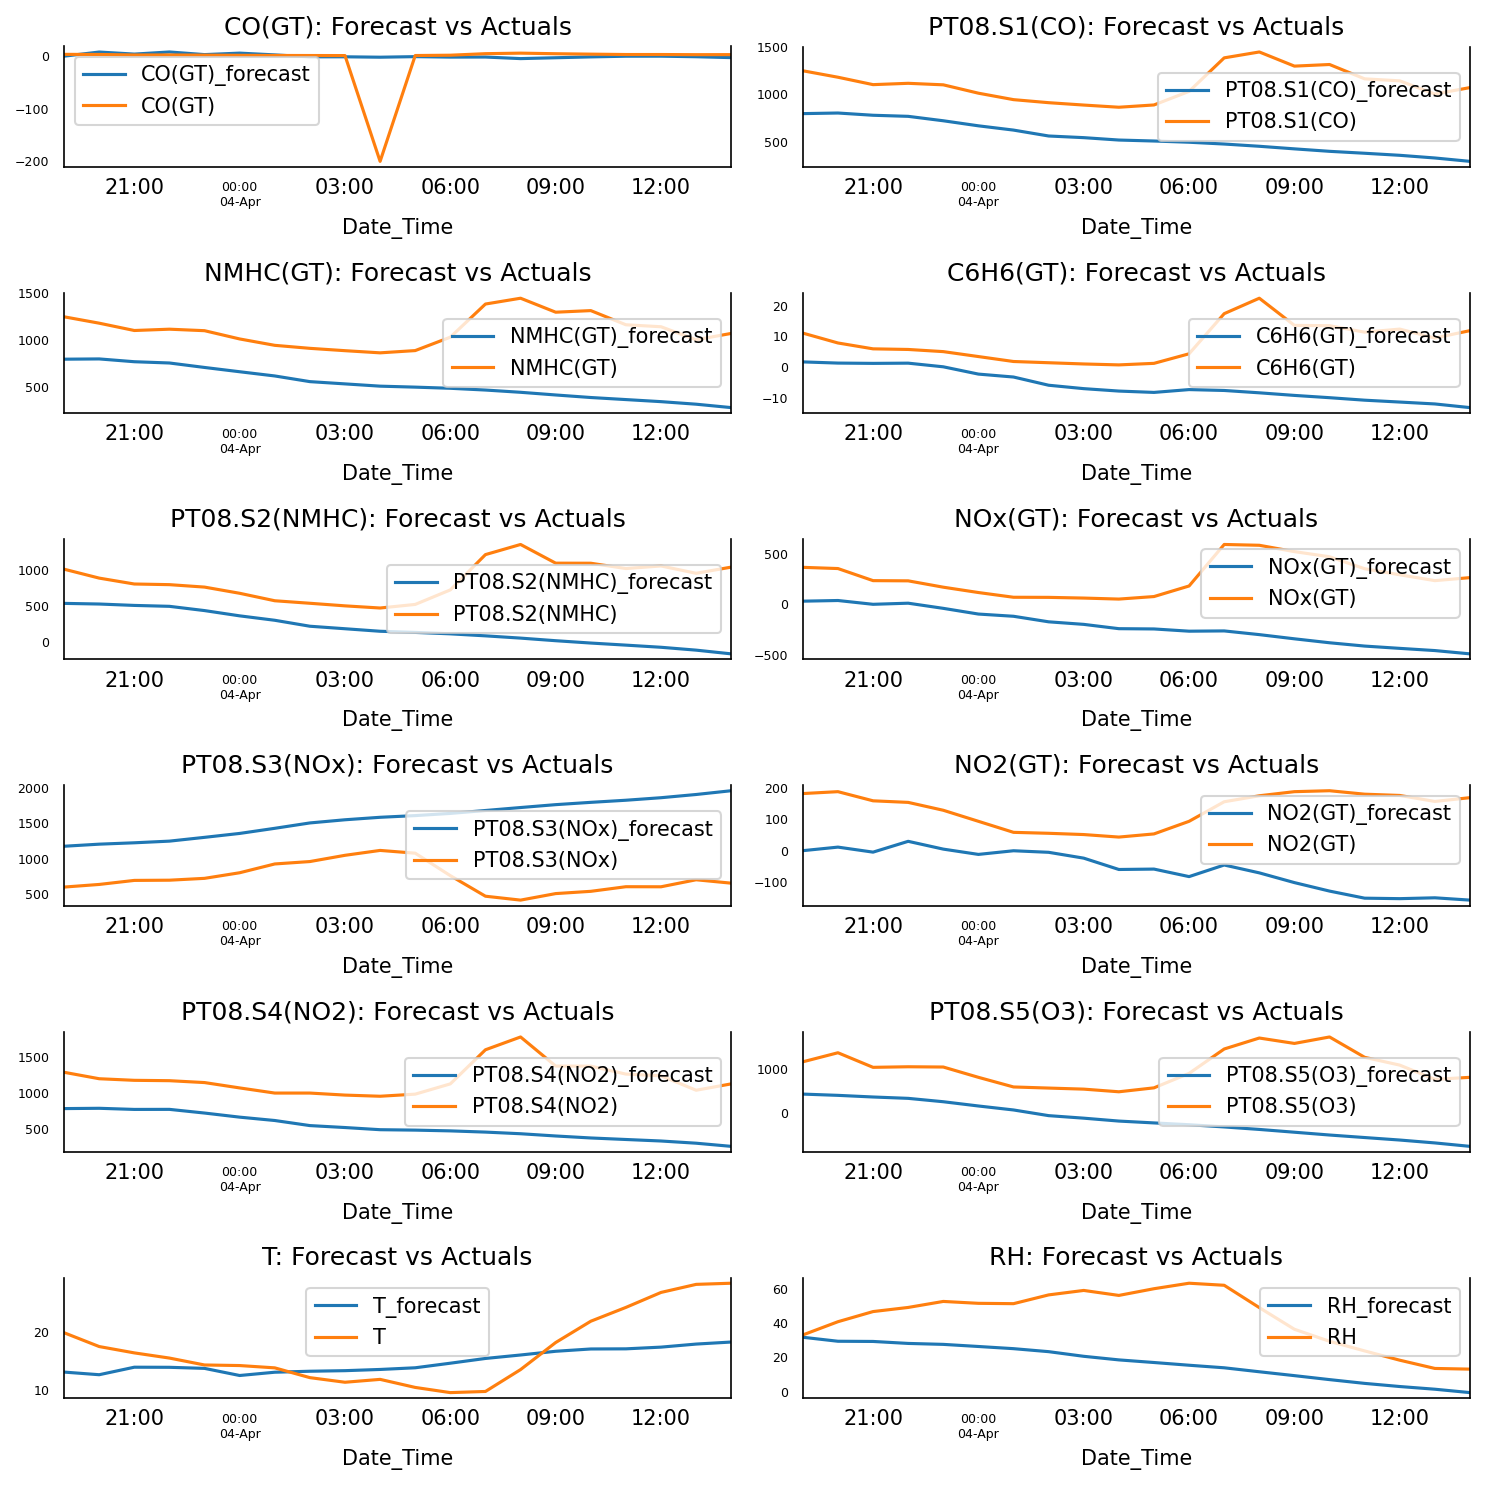

In [31]:
# отрисовываем


fig, axes = plt.subplots(nrows=int(len(df.columns)/2), ncols=2, dpi=150, figsize=(10,10))
for i, (col,ax) in enumerate(zip(df.columns, axes.flatten())):
    df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
    test[col][-nobs:].plot(legend=True, ax=ax);
    ax.set_title(col + ": Forecast vs Actuals")
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout();

In [32]:
# Метрики!

from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None], 
                              actual[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None], 
                              actual[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    return({'mape':mape, 'me':me, 'mae': mae, 
            'mpe': mpe, 'rmse':rmse, 'corr':corr, 'minmax':minmax})



In [33]:
cols = test.columns.to_list()

for vi in range(len(cols)):
    print(f'Forecast Accuracy of: {cols[vi]}')
    n1 = f"{cols[vi]}_forecast"
    accuracy_prod = forecast_accuracy(df_results[n1].values, np.array(test.iloc[len(test) - 20: len(test),vi]))
    for k, v in accuracy_prod.items():
        print(k, ': ', round(v,4))



Forecast Accuracy of: CO(GT)
mape :  2.4355
me :  7.8013
mae :  13.7474
mpe :  -1.0604
rmse :  44.3551
corr :  0.1504
minmax :  -1.7738
Forecast Accuracy of: PT08.S1(CO)
mape :  0.4947
me :  -559.9584
mae :  559.9584
mpe :  -0.4947
rmse :  608.9202
corr :  -0.0803
minmax :  0.4947
Forecast Accuracy of: NMHC(GT)
mape :  0.5035
me :  -569.4835
mae :  569.4835
mpe :  -0.5035
rmse :  618.2811
corr :  -0.08
minmax :  0.5035
Forecast Accuracy of: C6H6(GT)
mape :  2.7715
me :  -13.945
mae :  13.945
mpe :  -2.7715
rmse :  16.4383
corr :  -0.3294
minmax :  2.7715
Forecast Accuracy of: PT08.S2(NMHC)
mape :  0.7334
me :  -670.2068
mae :  670.2068
mpe :  -0.7334
rmse :  775.6613
corr :  -0.3588
minmax :  0.7334
Forecast Accuracy of: NOx(GT)
mape :  2.3215
me :  -485.0933
mae :  485.0933
mpe :  -2.3215
rmse :  553.9747
corr :  -0.2475
minmax :  2.3215
Forecast Accuracy of: PT08.S3(NOx)
mape :  1.3449
me :  839.6354
mae :  839.6354
mpe :  1.3449
rmse :  907.941
corr :  -0.2085
minmax :  0.5212
Forec

# Практические задания для самостоятельной работы

## Задание 1: Изменение горизонта прогнозирования
**Описание:** В лекционном примере мы предсказывали 20 точек (часов). Измените горизонт прогнозирования на 48 часов (двое суток). Сравните, как изменятся метрики качества (например, RMSE и MAPE) при увеличении горизонта.



CO(GT) стационарно (p=0.0000)


C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\3504440848.py:9: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("AirQualityUCI.csv", parse_dates=[['Date', 'Time']], sep=";", decimal=",")
C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\3504440848.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("AirQualityUCI.csv", parse_dates=[['Date', 'Time']], sep=";", decimal=",")


PT08.S1(CO) стационарно (p=0.0000)
NMHC(GT) стационарно (p=0.0000)
C6H6(GT) стационарно (p=0.0000)
PT08.S2(NMHC) стационарно (p=0.0000)
NOx(GT) стационарно (p=0.0000)
PT08.S3(NOx) стационарно (p=0.0000)
NO2(GT) стационарно (p=0.0000)
PT08.S4(NO2) стационарно (p=0.0000)
PT08.S5(O3) стационарно (p=0.0000)
T стационарно (p=0.0000)
RH стационарно (p=0.0000)
AH стационарно (p=0.0000)


c:\Users\Syoshi\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



Лучший порядок лага по AIC: 12
Модель обучена с лагом = 12

СРАВНЕНИЕ МЕТРИК КАЧЕСТВА: 20 часов vs 48 часов

CO(GT):
MAPE: 156.09%
RMSE: 1.5434
Корреляция: 0.4102

PT08.S1(CO):
MAPE: 40.11%
RMSE: 450.5034
Корреляция: 0.6218

NMHC(GT):
MAPE: 20.83%
RMSE: 242.7579
Корреляция: 0.6153


C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\3504440848.py:53: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_forecast = pd.DataFrame(fc, index=pd.date_range(start=test.index[0], periods=nobs, freq='H'),


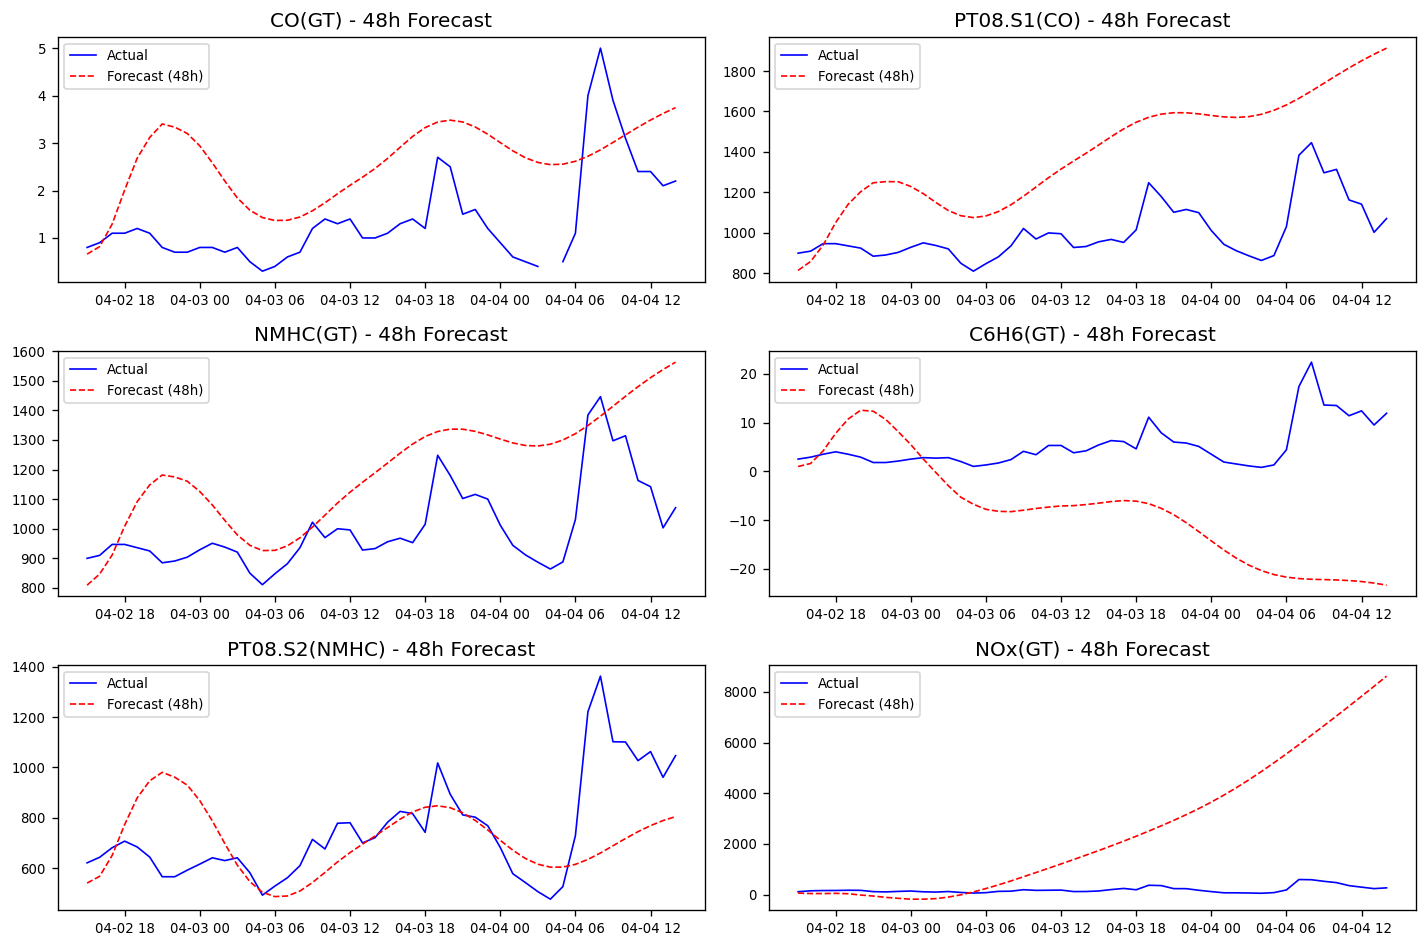

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

# Загрузка и подготовка данных (как в лекции)
df = pd.read_csv("AirQualityUCI.csv", parse_dates=[['Date', 'Time']], sep=";", decimal=",")
df['Date_Time'] = pd.to_datetime(df.Date_Time, format='%d/%m/%Y %H.%M.%S')
data = df.drop(['Date_Time'], axis=1)
data.index = df.Date_Time
df = data.copy()

# Заполнение пропусков (улучшенная версия)
df = df.replace(-200.0, np.nan).ffill(axis=1)

# Разделение на train (80%) и test (20%)
train = df[:int(0.8*(len(df)))]
test = df[int(0.8*(len(df))):]

# Приведение к стационарности (первая разность)
df_differenced = train.diff().dropna()

# Проверка стационарности
for col in df_differenced.columns:
    result = adfuller(df_differenced[col])
    if result[1] > 0.05:
        print(f"{col} не стационарно (p={result[1]:.4f})")
    else:
        print(f"{col} стационарно (p={result[1]:.4f})")

# Подбор оптимального лага
model = VAR(df_differenced)
lag_order_results = model.select_order(maxlags=12)
best_lag = lag_order_results.aic
print(f"\nЛучший порядок лага по AIC: {best_lag}")

# Обучение модели
model_fitted = model.fit(best_lag)
print(f"Модель обучена с лагом = {model_fitted.k_ar}")

nobs = 48  # ИЗМЕНЕНО с 20 на 48 часов 

# Подготовка входных данных для прогноза
lag_order = model_fitted.k_ar
forecast_input = df_differenced.values[-lag_order:]

# Прогнозирование
fc = model_fitted.forecast(y=forecast_input, steps=nobs)

# Создание DataFrame с прогнозом
df_forecast = pd.DataFrame(fc, index=pd.date_range(start=test.index[0], periods=nobs, freq='H'), 
                           columns=df.columns + '_2d')

# Функция обратного преобразования (с двойной разностью)
def invert_transformation(df_train, df_forecast, second_diff=True):
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:
        if second_diff:
            df_fc[str(col)+'_1d'] = (df_train[col].iloc[-1] - df_train[col].iloc[-2]) + df_fc[str(col)+'_2d'].cumsum()
        df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

# Обратное преобразование
df_results = invert_transformation(train, df_forecast, second_diff=True)

# Функция метрик качества
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual) / np.abs(actual)) * 100
    mae = np.mean(np.abs(forecast - actual))
    rmse = np.sqrt(np.mean((forecast - actual)**2))
    corr = np.corrcoef(forecast, actual)[0,1]
    return {'MAPE(%)': round(mape, 2), 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'CORR': round(corr, 4)}

# Сравнение метрик: 20 часов vs 48 часов
print("\n" + "="*60)
print("СРАВНЕНИЕ МЕТРИК КАЧЕСТВА: 20 часов vs 48 часов")
print("="*60)

for col in test.columns[:3]:
    actual_values = test[col][-nobs:].values
    forecast_values = df_results[f"{col}_forecast"][:len(actual_values)].values
    
    # Убираем возможные NaN
    mask = ~(np.isnan(actual_values) | np.isnan(forecast_values))
    actual_clean = actual_values[mask]
    forecast_clean = forecast_values[mask]
    
    if len(actual_clean) > 0:
        metrics = forecast_accuracy(forecast_clean, actual_clean)
        print(f"\n{col}:")
        print(f"MAPE: {metrics['MAPE(%)']}%")
        print(f"RMSE: {metrics['RMSE']}")
        print(f"Корреляция: {metrics['CORR']}")

# Визуализация для 48 часов
fig, axes = plt.subplots(nrows=3, ncols=2, dpi=120, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(test.columns[:6]):  # Первые 6 переменных
    actual_values = test[col][-nobs:].values
    forecast_values = df_results[f"{col}_forecast"][:len(actual_values)].values
    
    axes[i].plot(test.index[-nobs:], actual_values, label='Actual', color='blue', linewidth=1)
    axes[i].plot(test.index[-nobs:], forecast_values, label='Forecast (48h)', color='red', linewidth=1, linestyle='--')
    axes[i].set_title(f'{col} - 48h Forecast')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.show()


## Задание 2: Альтернативный метод заполнения пропусков (Интерполяция)
**Описание:** Вместо заполнения значения `-200` предыдущим известным значением, используйте линейную интерполяцию для восстановления пропущенных данных.

1. Сделайте копию исходного датафрейма.
2. Замените все значения `-200.0` на `np.nan`.
3. Примените метод Pandas `.interpolate(method='linear')`.
4. Выполните тест Дики-Фуллера

C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\1632157781.py:8: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("AirQualityUCI.csv", parse_dates=[['Date', 'Time']], sep=";", decimal=",")
C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\1632157781.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("AirQualityUCI.csv", parse_dates=[['Date', 'Time']], sep=";", decimal=",")
C:\Users\Syoshi\AppData\Local\Temp\ipykernel_28148\1632157781.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_interp = df_interp.fillna(method='bfill').fillna(method='ffill')



1. Статистика заполнения пропусков:
----------------------------------------
Исходное кол-во значений -200: 16701
После forward fill: 2075 пропусков
После интерполяции: 0 пропусков


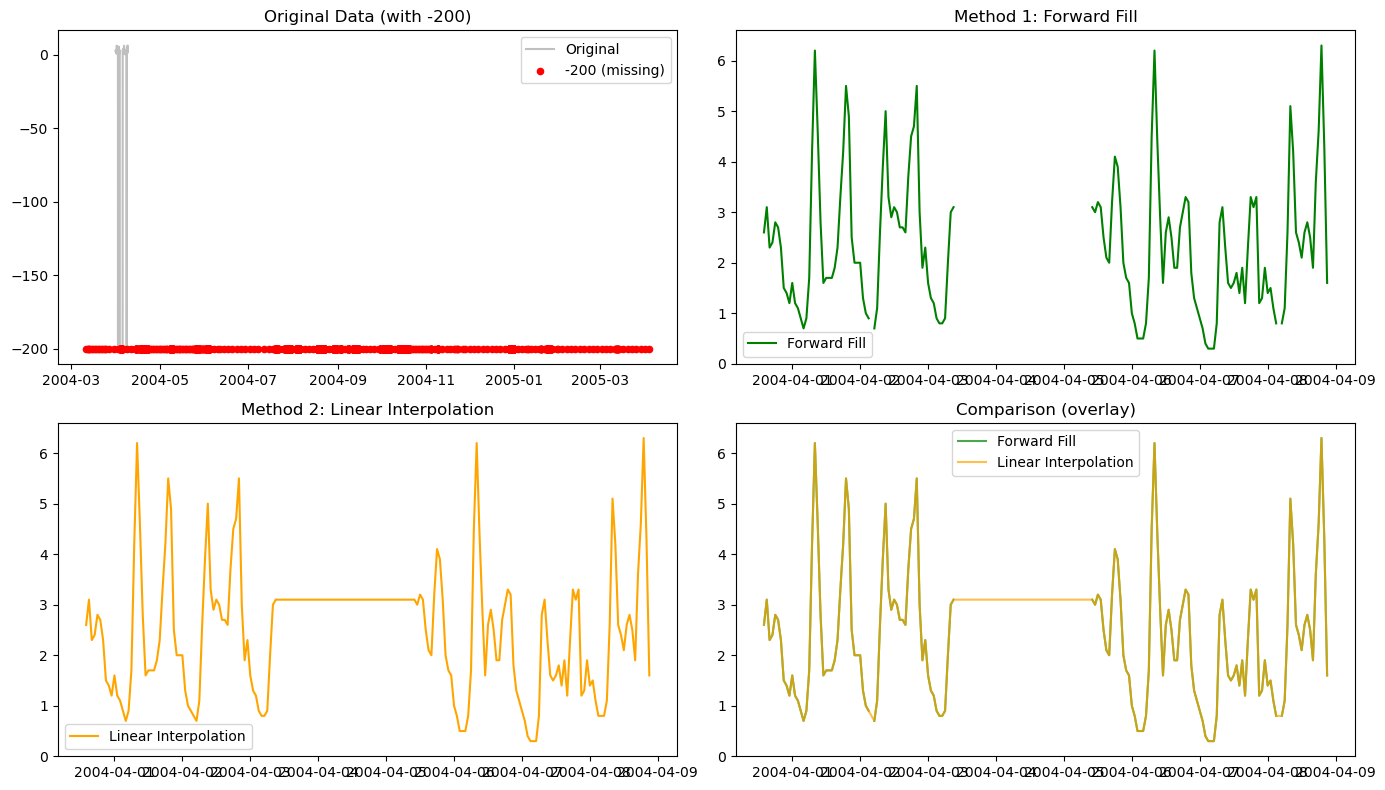

2. ТЕСТ ДИКИ-ФУЛЛЕРА ДЛЯ СТАЦИОНАРНОСТИ

--- Переменная: CO(GT) ---

Forward Fill:
   Test Statistic: -9.5560
   P-Value: 0.0000
   стационарный

Linear Interpolation:
   Test Statistic: -9.8727
   P-Value: 0.0000
   стационарный

--- Переменная: PT08.S1(CO) ---

Forward Fill:
   Test Statistic: -10.4540
   P-Value: 0.0000
   стационарный

Linear Interpolation:
   Test Statistic: -9.5523
   P-Value: 0.0000
   стационарный

--- Переменная: NMHC(GT) ---

Forward Fill:
   Test Statistic: -8.3168
   P-Value: 0.0000
   стационарный

Linear Interpolation:
   Test Statistic: -10.5979
   P-Value: 0.0000
   стационарный
3. СРАВНЕНИЕ КАЧЕСТВА ПРОГНОЗИРОВАНИЯ VAR

Средняя MAE (Forward Fill): 631.2414
Средняя MAE (Linear Interpolation): 407.4894

Вывод:
Linear Interpolation показал лучшее качество прогнозирования (MAE=407.4894 < 631.2414)


c:\Users\Syoshi\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Syoshi\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Загрузка исходных данных
df = pd.read_csv("AirQualityUCI.csv", parse_dates=[['Date', 'Time']], sep=";", decimal=",")
df['Date_Time'] = pd.to_datetime(df.Date_Time, format='%d/%m/%Y %H.%M.%S')
data = df.drop(['Date_Time'], axis=1)
data.index = df.Date_Time
df_original = data.copy()



# МЕТОД 1: Forward Fill
df_ffill = df_original.copy()
df_ffill = df_ffill.replace(-200.0, np.nan).ffill(axis=1)

# МЕТОД 2: Линейная интерполяция
df_interp = df_original.copy()
df_interp = df_interp.replace(-200.0, np.nan)

#Применяем линейную интерполяцию
for col in df_interp.columns:
    df_interp[col] = df_interp[col].interpolate(method='linear')

# Проверяем, остались ли пропуски в начале/конце (если да - заполняем ближайшим)
df_interp = df_interp.fillna(method='bfill').fillna(method='ffill')

print("\n1. Статистика заполнения пропусков:")
print("-" * 40)
print(f"Исходное кол-во значений -200: {(df_original == -200.0).sum().sum()}")
print(f"После forward fill: {(df_ffill.isna().sum().sum())} пропусков")
print(f"После интерполяции: {(df_interp.isna().sum().sum())} пропусков")

# 2 Визуальное сравнение методов на примере одной переменной
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sample_col = 'CO(GT)'
sample_range = slice(500, 700)  # покажем небольшой участок для наглядности

axes[0, 0].plot(df_original[sample_col].iloc[sample_range], label='Original', color='gray', alpha=0.5)
axes[0, 0].scatter(df_original[df_original[sample_col] == -200.0].index, 
                   [-200] * (df_original[sample_col] == -200.0).sum(), 
                   color='red', s=20, label='-200 (missing)', zorder=5)
axes[0, 0].set_title('Original Data (with -200)')
axes[0, 0].legend()

axes[0, 1].plot(df_ffill[sample_col].iloc[sample_range], label='Forward Fill', color='green')
axes[0, 1].set_title('Method 1: Forward Fill')
axes[0, 1].legend()

axes[1, 0].plot(df_interp[sample_col].iloc[sample_range], label='Linear Interpolation', color='orange')
axes[1, 0].set_title('Method 2: Linear Interpolation')
axes[1, 0].legend()

axes[1, 1].plot(df_ffill[sample_col].iloc[sample_range], label='Forward Fill', color='green', alpha=0.7)
axes[1, 1].plot(df_interp[sample_col].iloc[sample_range], label='Linear Interpolation', color='orange', alpha=0.7)
axes[1, 1].set_title('Comparison (overlay)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 3 Тест Дики-Фуллера для обоих методов
def adfuller_report(series, name, signif=0.05):
    result = adfuller(series.dropna(), autolag='AIC')
    p_value = result[1]
    is_stationary = p_value <= signif
    status = "стационарный" if is_stationary else "нестационарнгый"
    print(f"\n{name}:")
    print(f"   Test Statistic: {result[0]:.4f}")
    print(f"   P-Value: {p_value:.4f}")
    print(f"   {status}")
    return is_stationary, p_value

print("2. ТЕСТ ДИКИ-ФУЛЛЕРА ДЛЯ СТАЦИОНАРНОСТИ")
print("="*60)

results = []
for col in df_ffill.columns[:3]:  # Проверяем первые 3 колонки
    print(f"\n--- Переменная: {col} ---")
    stat1, p1 = adfuller_report(df_ffill[col], "Forward Fill")
    stat2, p2 = adfuller_report(df_interp[col], "Linear Interpolation")
    results.append({'col': col, 'ffill_pvalue': p1, 'interp_pvalue': p2})

# 4 Сравнение качества прогнозирования VAR с разными методами
print("3. СРАВНЕНИЕ КАЧЕСТВА ПРОГНОЗИРОВАНИЯ VAR")
print("="*60)

def evaluate_var_method(df_filled, method_name, nobs=20):
    """Оценивает VAR модель на данных, заполненных определенным методом"""
    # Разделение
    train = df_filled[:int(0.8*(len(df_filled)))]
    test = df_filled[int(0.8*(len(df_filled))):]
    
    # Дифференцирование для стационарности
    train_diff = train.diff().dropna()
    
    # Проверка, что нет бесконечных значений
    train_diff = train_diff.replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(train_diff) < 10:
        return None
    
    try:
        # VAR модель
        model = VAR(train_diff)
        best_lag = model.select_order(maxlags=min(5, len(train_diff)//2)).aic
        if best_lag is None or best_lag <= 0:
            best_lag = 1
        model_fitted = model.fit(best_lag)
        
        # Прогноз
        lag_order = model_fitted.k_ar
        if len(train_diff) > lag_order:
            forecast_input = train_diff.values[-lag_order:]
            fc = model_fitted.forecast(y=forecast_input, steps=min(nobs, len(test)))
            
            # Простая метрика (средняя ошибка по всем колонкам)
            mae_scores = []
            for i, col in enumerate(test.columns[:3]):  # берем первые 3 колонки
                if i < fc.shape[1]:
                    actual = test[col].iloc[:len(fc)].values
                    pred = fc[:, i]
                    mae = np.mean(np.abs(actual - pred))
                    if not np.isnan(mae) and not np.isinf(mae):
                        mae_scores.append(mae)
            
            if mae_scores:
                return np.mean(mae_scores)
    except Exception as e:
        print(f"  Ошибка при {method_name}: {str(e)[:50]}")
        return None
    
    return None

# Сравнение
score_ffill = evaluate_var_method(df_ffill, "Forward Fill")
score_interp = evaluate_var_method(df_interp, "Linear Interpolation")

print(f"\nСредняя MAE (Forward Fill): {score_ffill:.4f}" if score_ffill else "Forward Fill: не удалось обучить модель")
print(f"Средняя MAE (Linear Interpolation): {score_interp:.4f}" if score_interp else "Linear Interpolation: не удалось обучить модель")

print(f"\nВывод:")
if score_ffill and score_interp:
    if score_ffill < score_interp:
        print(f"Forward Fill показал лучшее качество прогнозирования (MAE={score_ffill:.4f} < {score_interp:.4f})")
    else:
        print(f"Linear Interpolation показал лучшее качество прогнозирования (MAE={score_interp:.4f} < {score_ffill:.4f})")
        